In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings         
warnings.filterwarnings('ignore')


In [4]:
# Load dataset
df = pd.read_csv("WorldEnergy.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [5]:
display(df.head())
df.shape 

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


(23195, 130)

In [6]:
df.isna().sum()

country                       0
year                          0
iso_code                   6096
population                 4466
gdp                       11415
                          ...  
wind_elec_per_capita      14894
wind_electricity          13324
wind_energy_per_capita    18050
wind_share_elec           15327
wind_share_energy         16816
Length: 130, dtype: int64

In [7]:

# 5. 确定我们要分析的国家和年份范围
target_countries = ['China', 'Germany', 'India', 'Brazil', 'United States']
min_year = 1990

In [8]:
# 6. 提取子集
df_sub = df[df['country'].isin(target_countries) & (df['year'] >= min_year)].copy()

In [10]:
df_sub.info()
display(df_sub.head())
df_sub.shape

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 3058 to 21820
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 179.1+ KB


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
3058,Brazil,1990,BRA,149143183.0,1.185475e+12,-7.819,-6.260,494.838,73.802,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3059,Brazil,1991,BRA,151724204.0,1.213090e+12,1.715,1.266,494.764,75.068,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3060,Brazil,1992,BRA,154275022.0,1.221829e+12,-1.954,-1.467,477.076,73.601,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3061,Brazil,1993,BRA,156794519.0,1.298221e+12,5.633,4.146,495.851,77.747,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3062,Brazil,1994,BRA,159264962.0,1.391784e+12,7.429,5.775,524.423,83.522,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(175, 130)

In [11]:
df_sub['country'].unique()

array(['Brazil', 'China', 'Germany', 'India', 'United States'],
      dtype=object)

In [12]:
df_sub['year'].min(), "-", df_sub['year'].max()

(1990, '-', 2024)

In [35]:
key_cols = key_cols = ['country',	'year',	'iso_code',	'population',	'gdp',
                       'renewables_share_elec', 'coal_share_elec', 'gas_share_elec', 
                       'carbon_intensity_elec', 'per_capita_electricity','fossil_share_elec', 
                       'nuclear_share_elec', 'electricity_generation']
df_sub[key_cols].info()


<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 3058 to 21820
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 175 non-null    object 
 1   year                    175 non-null    int64  
 2   iso_code                175 non-null    object 
 3   population              175 non-null    float64
 4   gdp                     165 non-null    float64
 5   renewables_share_elec   175 non-null    float64
 6   coal_share_elec         175 non-null    float64
 7   gas_share_elec          175 non-null    float64
 8   carbon_intensity_elec   125 non-null    float64
 9   per_capita_electricity  175 non-null    float64
 10  fossil_share_elec       175 non-null    float64
 11  nuclear_share_elec      175 non-null    float64
 12  electricity_generation  175 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 19.1+ KB


In [36]:
display(df_sub[key_cols].head())
df_sub[key_cols].shape 


,country,year,iso_code,population,gdp,renewables_share_elec,coal_share_elec,gas_share_elec,carbon_intensity_elec,per_capita_electricity,fossil_share_elec,nuclear_share_elec,electricity_generation
3058,Brazil,1990,BRA,149143183.0,1.185475e+12,94.501,2.074,0.146,NaN,1494.001,4.495,1.004,222.820
3059,Brazil,1991,BRA,151724204.0,1.213090e+12,94.626,2.361,0.159,NaN,1544.752,4.758,0.615,234.376
3060,Brazil,1992,BRA,154275022.0,1.221829e+12,94.420,2.071,0.161,NaN,1567.084,4.852,0.728,241.762
3061,Brazil,1993,BRA,156794519.0,1.298221e+12,95.256,1.948,0.154,NaN,1607.219,4.568,0.175,252.003
3062,Brazil,1994,BRA,159264962.0,1.391784e+12,95.406,1.911,0.184,NaN,1632.755,4.573,0.021,260.041


(175, 13)

In [37]:
df_sub[key_cols].isna().sum()

country                    0
year                       0
iso_code                   0
population                 0
gdp                       10
renewables_share_elec      0
coal_share_elec            0
gas_share_elec             0
carbon_intensity_elec     50
per_capita_electricity     0
fossil_share_elec          0
nuclear_share_elec         0
electricity_generation     0
dtype: int64

In [38]:
# 定义要检查的关键指标
key_cols = key_cols = ['country',	'year',	'iso_code',	'population',	'gdp',
                       'renewables_share_elec', 'coal_share_elec', 'gas_share_elec', 
                       'carbon_intensity_elec', 'per_capita_electricity','fossil_share_elec', 
                       'nuclear_share_elec', 'electricity_generation']

# 1. 缺失数量表格
print("\n=== 每个国家在各关键指标上的缺失数量 ===")
missing_count = pd.DataFrame(index=target_countries, columns=key_cols)

for country in target_countries:
    sub = df_sub[df_sub['country'] == country]
    for col in key_cols:
        missing_count.loc[country, col] = sub[col].isna().sum()

print(missing_count)

# 2. 缺失具体年份详情
print("\n=== 缺失年份详情 ===")
for country in target_countries:
    sub = df_sub[df_sub['country'] == country]
    for col in key_cols:
        missing_years = sub[sub[col].isna()]['year'].tolist()
        if missing_years:
            print(f"{country} - {col}: 缺失年份 {missing_years}")


=== 每个国家在各关键指标上的缺失数量 ===
              country year iso_code population gdp renewables_share_elec  \
China               0    0        0          0   2                     0   
Germany             0    0        0          0   2                     0   
India               0    0        0          0   2                     0   
Brazil              0    0        0          0   2                     0   
United States       0    0        0          0   2                     0   

              coal_share_elec gas_share_elec carbon_intensity_elec  \
China                       0              0                    10   
Germany                     0              0                    10   
India                       0              0                    10   
Brazil                      0              0                    10   
United States               0              0                    10   

              per_capita_electricity fossil_share_elec nuclear_share_elec  \
China              

In [49]:
df_subset_before = df_sub[key_cols]
df_subset_before.shape


(175, 13)

In [50]:
#
df_subset_after = subset_before.drop(["iso_code"], axis=1)           
df_subset_after.shape 

(175, 12)

In [81]:
stats_cols = [col for col in key_cols if col != 'year']

stats_all = df_sub.groupby('country')[stats_cols].describe()
stats_all

population                                            \
                   count          mean           std           min   
country                                                              
Brazil              35.0  1.856659e+08  1.938097e+07  1.491432e+08   
China               35.0  1.320101e+09  8.478710e+07  1.153583e+09   
Germany             35.0  8.205913e+07  1.169654e+06  7.970791e+07   
India               35.0  1.179060e+09  1.810664e+08  8.649722e+08   
United States       35.0  3.018779e+08  2.890196e+07  2.533733e+08   

                                                                        gdp  \
                        25%           50%           75%           max count   
country                                                                       
Brazil         1.704005e+08  1.885523e+08  2.024468e+08  2.119985e+08  33.0   
China          1.255512e+09  1.325814e+09  1.400093e+09  1.426437e+09  33.0   
Germany        8.120462e+07  8.201188e+07  8.257482e+07  8.455219e+07  33.0   
India          1.028445e+09  1.190676e+09  1.335984e+09  1.450936e+09  33.0   
United States  2.774524e+08  3.018442e+08  3.276529e+08  3.454265e+08  33.0   

                             ... nuclear_share_elec          \
                       mean  ...                75%     max   
country                      ...                              
Brazil         2.262926e+12  ...             2.7975   4.346   
China          1.171751e+13  ...             3.2115   4.775   
Germany        3.049515e+12  ...            28.8840  31.175   
India          4.891528e+12  ...             2.8020   3.223   
United States  1.429605e+13  ...            19.7270  20.626   

              electricity_generation                                      \
                               count         mean          std       min   
country                                                                    
Brazil                          35.0   453.636714   155.198830   222.820   
China                           35.0  3912.317714  2936.592632   621.200   
Germany                         35.0   581.624286    45.382840   476.870   
India                           35.0   946.714714   522.656860   287.763   
United States                   35.0  3913.156800   299.917963  3232.780   

                                                      
                     25%      50%      75%       max  
country                                               
Brazil          325.1495   445.15   585.27    745.26  
China          1203.1500  3281.54  5973.87  10072.60  
Germany         547.3000   583.76   622.01    644.46  
India           526.2200   796.26  1361.92   2057.54  
United States  3764.8350  4040.67  4101.77   4387.26  

[5 rows x 80 columns]

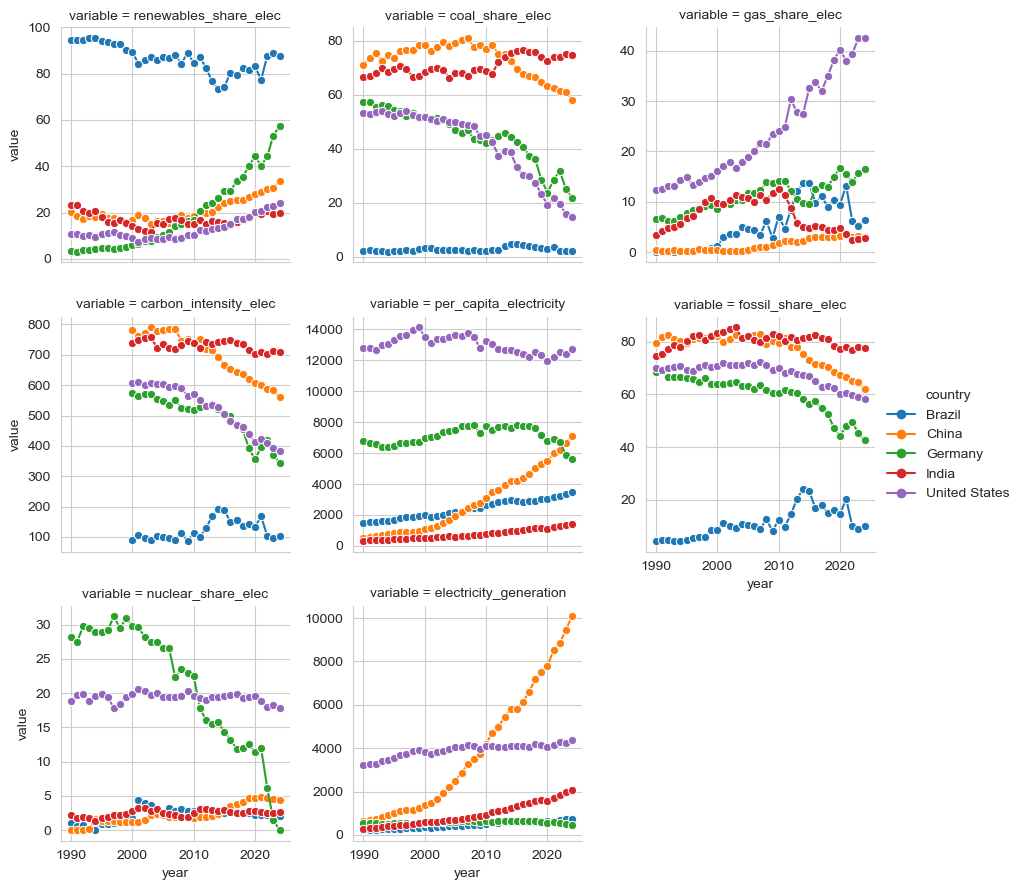

In [141]:
df_melt = df_plot.melt(id_vars=['year','country'], 
                       value_vars=['renewables_share_elec','coal_share_elec','gas_share_elec',
                                   'carbon_intensity_elec','per_capita_electricity',
                                   'fossil_share_elec','nuclear_share_elec','electricity_generation'])
# 碳强度只保留2000年后
df_melt = df_melt[~((df_melt['variable']=='carbon_intensity_elec') & (df_melt['year']<2000))]

sns.relplot(data=df_melt, x='year', y='value', col='variable', col_wrap=3,
            hue='country', kind='line', marker='o', height=3, facet_kws={'sharey': False})
plt.show()

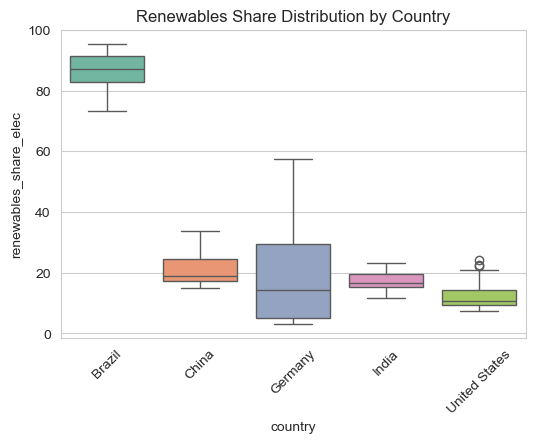

In [126]:
# 1. 箱线图：各国可再生能源占比分布（看中位数、异常值）
sns.boxplot(data=df_plot, x='country', y='renewables_share_elec', palette='Set2')
plt.title('Renewables Share Distribution by Country')
plt.xticks(rotation=45)
plt.show()

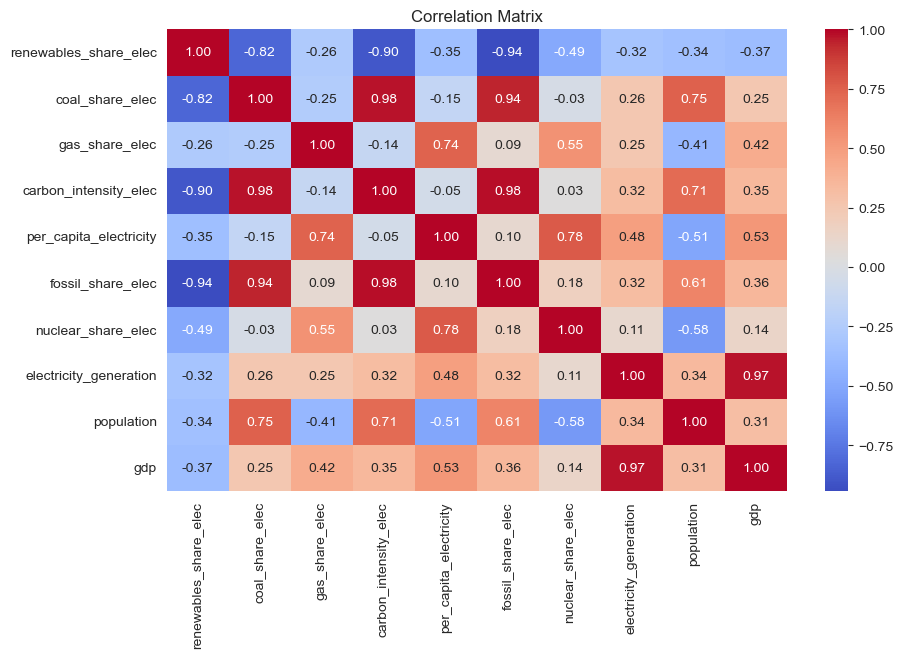

In [144]:
# 4. 热力图：所有数值指标的相关性（包括人口、GDP、各类能源占比）
numeric_cols = ['renewables_share_elec', 'coal_share_elec', 'gas_share_elec',
                'carbon_intensity_elec', 'per_capita_electricity',
                'fossil_share_elec', 'nuclear_share_elec', 'electricity_generation',
                'population', 'gdp']
corr = df_plot[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

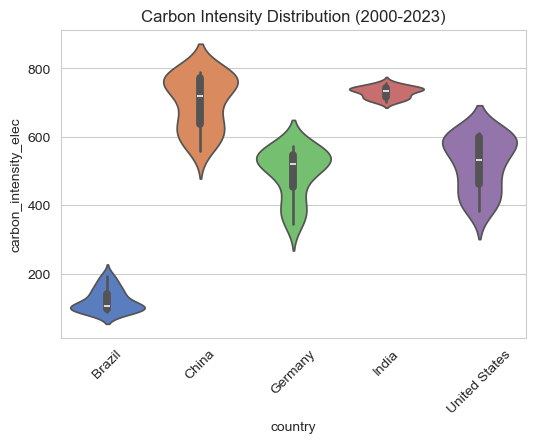

In [122]:
# 6. 小提琴图：各国碳排放强度的分布（2000年后）
plt.figure(figsize=(6,4))
df_carbon = df_plot[df_plot['year'] >= 2000]
sns.violinplot(data=df_carbon, x='country', y='carbon_intensity_elec', palette='muted')
plt.title('Carbon Intensity Distribution (2000-2023)')
plt.xticks(rotation=45)
plt.show()


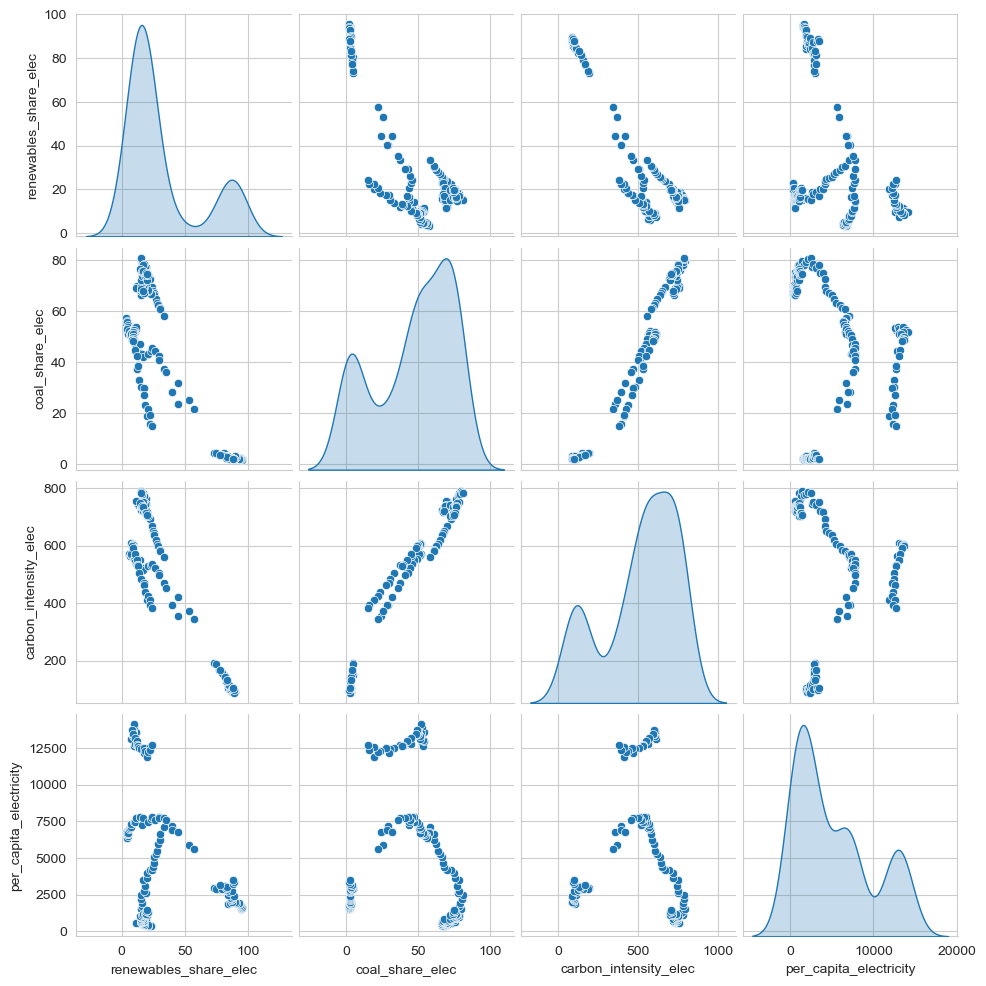

In [66]:
# 7. 配对图：选取几个关键数值变量，看两两关系
sns.pairplot(df_plot[['renewables_share_elec', 'coal_share_elec', 'carbon_intensity_elec', 'per_capita_electricity']], diag_kind='kde')
plt.show()

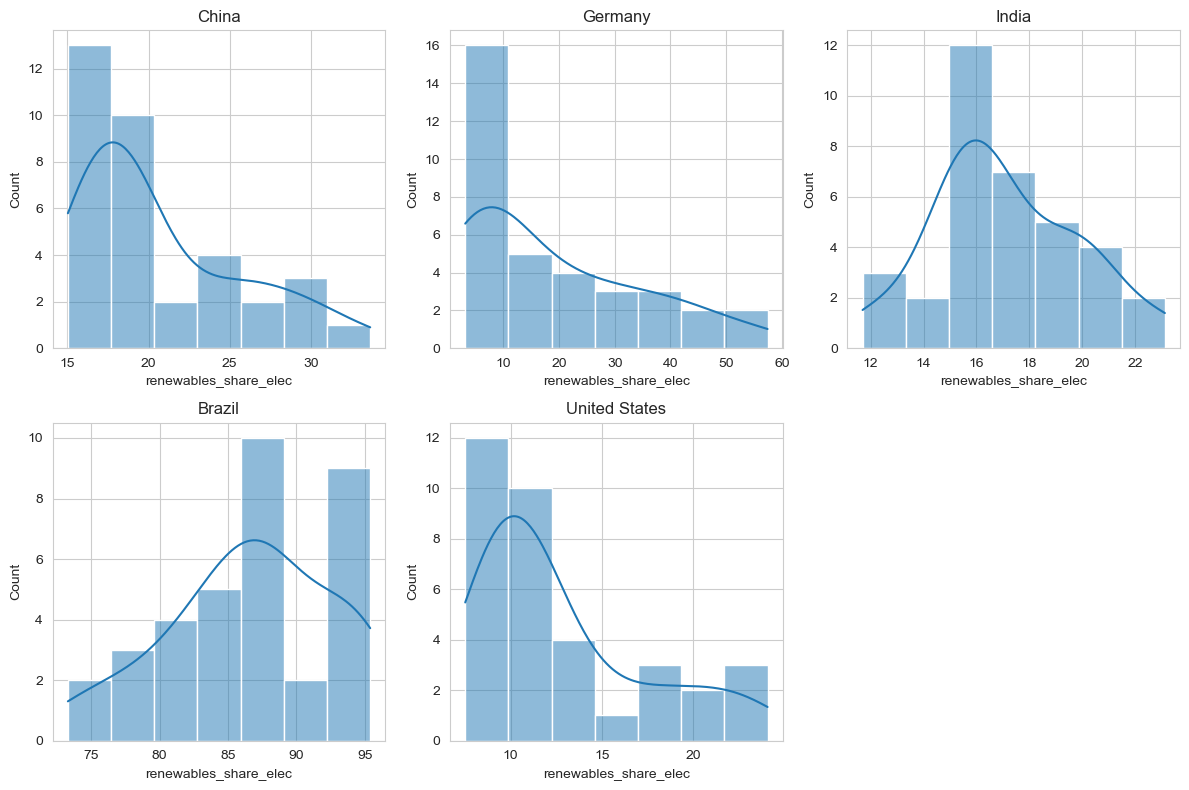

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, country in enumerate(target_countries):
    ax = axes[idx//3, idx%3]
    data = df_plot[df_plot['country'] == country]['renewables_share_elec'].dropna()
    sns.histplot(data, kde=True, ax=ax)
    ax.set_title(country)
axes[1,2].axis('off')
plt.tight_layout()
plt.show()

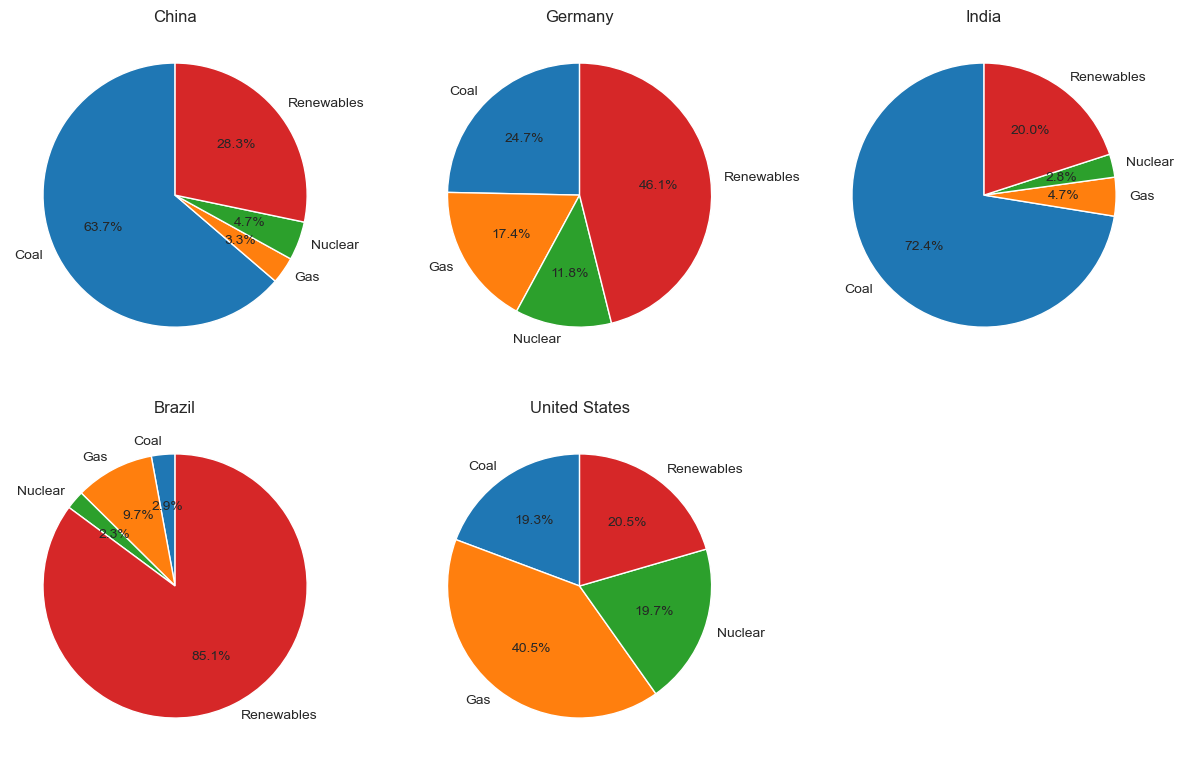

In [145]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, country in enumerate(target_countries):
    row = df_plot[(df_plot['country'] == country) & (df_plot['year'] == 2020)].iloc[0]
    axes[i//3, i%3].pie([row['coal_share_elec'], row['gas_share_elec'], 
                         row['nuclear_share_elec'], row['renewables_share_elec']],
                        labels=['Coal','Gas','Nuclear','Renewables'], autopct='%1.1f%%', startangle=90)
    axes[i//3, i%3].set_title(country)
axes[1,2].axis('off')
plt.tight_layout()
plt.show()